# Satellite Image Changes and 10-Minute Forecasting over Ireland

This notebook uses **six EUMETSAT satellite images** from **20 September 2026, 14:00–14:50 UTC**, with one image every 10 minutes. Each pixel contains an infrared **brightness temperature**, measured in **kelvin (K)**. Here, `temperature` refers to these satellite values, not a ground-level air-temperature measurement.

We ask two questions: **How do the images change over time?** And **can a small CNN predict the next image?**

| Part | What the model does |
|:---|:---|
| Compare changes | A ready-made ResNet18 turns each image into a list of numbers called *features*. We compare these lists between times. |
| Make a forecast | A separate, small CNN learns from the earlier images and predicts the change over the next 10 minutes. |

**Run from top to bottom** in your existing project folder. Keep your private `Keys.csv` in that folder. The first run may need to download satellite data and model weights. The plots and printed results below are preserved from the uploaded notebook; they have not been regenerated for this commented version.


## 1. Choose the data and load libraries

This cell loads the tools and sets the region, time window, channel, and folders. `BBOX` gives the west, south, east, and north limits. The search covers 14:00–15:00 UTC, but the end time is excluded when observations are selected.

All images will use the same **280-row × 360-column grid**. This makes their pixel positions comparable; it does not add detail to the original measurements. The satellite channel is `ir_105`, from collection `EO:EUM:DAT:0662`.


In [1]:
# %pip install eumdac numpy matplotlib satpy pyresample hdf5plugin netCDF4 cartopy shapely
# Read files, manage folders, and support the later calculations.
import csv
import datetime
import hashlib
import json
import os
import re
import shutil
import urllib.request
from pathlib import Path
import copy
import datetime as dt
import random

# Tools for satellite data, arrays, and plots.
import eumdac
import numpy as np
import matplotlib.pyplot as plt
import hdf5plugin
# Make the JPEG-LS plugin discoverable by the NetCDF/HDF5 reader on Windows.
os.environ.setdefault("HDF5_PLUGIN_PATH", hdf5plugin.PLUGINS_PATH)
import netCDF4
# Read satellite files and place the images on a shared map grid.
from satpy import Scene
from pyresample import create_area_def
from shapely import wkt
from shapely.geometry import box
import cartopy
import cartopy.crs as ccrs
# Tools for the two neural-network tasks.
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision.models import resnet18, ResNet18_Weights

# Choose the area around Ireland using longitude and latitude.
WEST, SOUTH, EAST, NORTH = -13.0, 50.0, -4.0, 57.0
BBOX = (WEST, SOUTH, EAST, NORTH)
# Use UTC throughout. Later selection excludes observations at END.
START = datetime.datetime(2026, 9, 20, 14, 0, tzinfo=datetime.timezone.utc)
END = datetime.datetime(2026, 9, 20, 15, 0, tzinfo=datetime.timezone.utc)
MAX_IMAGES = 6
# Select one satellite channel rather than a colour photograph.
CHANNEL = "ir_105"
COLLECTION_ID = "EO:EUM:DAT:0662"
# Keep downloaded data and figures in separate local folders.
ROOT = Path("data/ireland_fci")
ROOT.mkdir(parents=True, exist_ok=True)
cartopy.config["data_dir"] = ROOT / "cartopy"
RESULTS = Path("results/ireland_fci")
RESULTS.mkdir(parents=True, exist_ok=True)
# A common output grid; interpolation does not increase native sensor resolution.
AREA = create_area_def("ireland", "+proj=longlat +datum=WGS84", units="degrees",
                       area_extent=BBOX, shape=(280, 360))
# These limits control the overview plot, not the forecast training scale.
DISPLAY_MIN_K, DISPLAY_MAX_K = 180.0, 330.0
# Require at least 95% valid pixels during image preparation.
MIN_COVERAGE = 0.95


## 2. Connect to EUMETSAT

The code reads your access key and secret from `Keys.csv`, then opens the chosen data collection. In this version, the file must use **UTF-16 encoding**, and its **first row** must contain the key followed by the secret. The code does not skip a header row.

Do not share `Keys.csv` or include its contents in this notebook.


In [2]:
# Read the first row: key in the first column, secret in the second.
with open("Keys.csv", mode="r", encoding="utf-16") as file:
    reader = csv.reader(file)
    row = next(reader)

consumer_key = row[0]
consumer_secret = row[1]

# Use the credentials to connect without printing their values.
credentials = (consumer_key, consumer_secret)
token = eumdac.AccessToken(credentials)
datastore = eumdac.DataStore(token)
# Open the collection that will be searched in the next cell.
collection = datastore.get_collection("EO:EUM:DAT:0662")

## 3. Find complete observations

One observation is stored in several files called **chunks**. We first use a map to find the chunks covering our region, including a small margin around it. We then search the time window, put the observations in time order, and keep up to six complete observations.

The checks reject missing chunks and repeated times. The saved output shows which chunks were needed and how many observations were selected.


In [3]:
# This map tells us which part of the Earth each chunk covers.
MAP_URL = ("https://gitlab.eumetsat.int/api/v4/projects/2399/repository/files/"
           "FCI_chunks.wkt/raw?ref=241ba1dba9b81ece8bfda588a1453e7c6c88f518")
# A file fingerprint checks that we use the expected map version.
MAP_SHA256 = "f5b6a0962df24a80921addec2e4ac6e54233f9b0faedd079dddc7405fa87105c"
map_path = ROOT / "FCI_chunks.wkt"
# Download the map only when it is not already saved.
if not map_path.exists():
    with urllib.request.urlopen(MAP_URL, timeout=90) as response:
        map_bytes = response.read()
    if hashlib.sha256(map_bytes).hexdigest() != MAP_SHA256:
        raise ValueError("Footprint map checksum differs; review the source version.")
    map_path.write_bytes(map_bytes)
if hashlib.sha256(map_path.read_bytes()).hexdigest() != MAP_SHA256:
    raise ValueError("Cached footprint map checksum differs.")

# Add a small margin so data just outside the region can also be included.
padded_roi = box(WEST - 0.25, SOUTH - 0.25, EAST + 0.25, NORTH + 0.25)
chunk_ids = set()
# Keep the chunk numbers whose map areas overlap our region.
for line in map_path.read_text().splitlines():
    chunk_id, polygon_text = line.split(",", 1)
    polygon = wkt.loads(polygon_text)
    if not polygon.is_valid:
        # Try to repair an invalid boundary shape.
        polygon = polygon.buffer(0)
    if padded_roi.intersects(polygon):
        chunk_ids.add(int(chunk_id))
if not chunk_ids:
    raise ValueError("No chunks intersect the region.")
print("Required observation chunks:", sorted(chunk_ids))

# Read the observation start time from the product name.
def sensing_start(product):
    match = re.search(r"_OPE_(\d{14})_(\d{14})_", str(product))
    if match is None:
        raise ValueError("Unrecognized product naming; verify sensing-time metadata.")
    return datetime.datetime.strptime(match[1], "%Y%m%d%H%M%S").replace(tzinfo=datetime.timezone.utc)

# Find observations and sort them from earliest to latest.
products = sorted(list(collection.search(dtstart=START, dtend=END)), key=sensing_start)
selected = []
skipped = 0
seen_times = set()
for product in products:
    observed_at = sensing_start(product)
    # Skip times outside the window and avoid using the same time twice.
    if not START <= observed_at < END or observed_at in seen_times:
        continue
    bodies, trailers = {}, []
    # Collect the required image chunks and the listed trailer files.
    for entry in product.entries:
        match = re.search(r"_(\d{4})\.nc$", entry)
        if match and "CHK-BODY" in entry and int(match[1]) in chunk_ids:
            chunk = int(match[1])
            if chunk in bodies:
                raise ValueError("Duplicate raw chunk in a product; review the product entries.")
            bodies[chunk] = entry
        elif entry.endswith(".nc") and "CHK-TRAIL" in entry:
            trailers.append(entry)
    # Skip the observation when any required image chunk is missing.
    if set(bodies) != chunk_ids:
        skipped += 1
        continue
    # Store the files and time needed by the download step.
    selected.append(dict(product=product, time=observed_at,
                         body_entries=[bodies[i] for i in sorted(bodies)], trailers=trailers))
    seen_times.add(observed_at)
    if len(selected) >= MAX_IMAGES:
        break
print(f"Search: {len(products)} products; selected: {len(selected)}; incomplete products skipped: {skipped}.")
if not selected:
    raise ValueError("No complete raw-data products for this region. Try another time window.")


Required observation chunks: [37, 38]
Search: 6 products; selected: 6; incomplete products skipped: 0.


## 4. Download and prepare each image

These functions download the selected files, read the channel as brightness temperature, crop the region, and place the values on our common grid. Files already on disk are reused when they can be opened.

Unusable values are marked as missing. This stage requires at least **95% valid pixels**; a later check requires every pixel to be valid before model training. The map-drawing function adds coastlines only to the plot, not to the values used by the models.


In [4]:
# Check whether a local file can be opened as NetCDF.
def valid_netcdf(path):
    try:
        with netCDF4.Dataset(path):
            return True
    except (OSError, RuntimeError):
        return False

# Download one observation, reusing files that can already be opened.
def download_observation(record):
    product_id = str(record["product"])
    # Add a short product tag to the folder name.
    suffix = hashlib.sha256(product_id.encode()).hexdigest()[:8]
    folder = ROOT / (record["time"].strftime("%Y%m%dT%H%M%S") + "_" + suffix)
    folder.mkdir(exist_ok=True)
    body_paths = []
    for entry in record["body_entries"] + record["trailers"]:
        path = folder / Path(entry).name
        if not path.exists() or not valid_netcdf(path):
            # Use a temporary name so an unfinished download is not mistaken for a full file.
            part = path.with_suffix(".nc.part")
            try:
                with record["product"].open(entry=entry) as source, part.open("wb") as dest:
                    shutil.copyfileobj(source, dest)
            except Exception as error:
                raise RuntimeError(f"Chunk download failed ({type(error).__name__}); rerun to retry.") from None
            if not valid_netcdf(part):
                raise ValueError("Downloaded file is not readable NetCDF; rerun to retry.")
            # Rename the file only after it has downloaded and can be opened.
            part.replace(path)
        # Return only image-chunk paths for the satellite reader.
        if entry in record["body_entries"]:
            body_paths.append(str(path))
    return body_paths

# Turn the downloaded files into one 2D brightness-temperature image.
def process_observation(record):
    paths = download_observation(record)
    scene = Scene(reader="fci_l1c_nc", filenames=paths)
    # Read the chosen channel as brightness temperature, measured in K.
    scene.load([CHANNEL], calibration="brightness_temperature", upper_right_corner="NE")
    # Keep the region plus its small margin, then use the same grid for every time.
    cropped = scene.crop(ll_bbox=(WEST - 0.25, SOUTH - 0.25, EAST + 0.25, NORTH + 0.25))
    regional = cropped.resample(AREA, resampler="nearest", radius_of_influence=10000)
    field = regional[CHANNEL]
    if field.attrs.get("units") != "K":
        raise ValueError("Expected brightness temperatures in kelvin; inspect calibration.")
    values = np.asarray(field.compute().values, dtype=np.float32)
    # Mark invalid or non-positive values as missing instead of using them.
    values[~np.isfinite(values) | (values <= 0)] = np.nan
    if values.shape != (AREA.height, AREA.width):
        raise ValueError("Unexpected output grid shape.")
    # Calculate the fraction of pixels that contain usable values.
    coverage = np.isfinite(values).mean()
    if coverage < MIN_COVERAGE:
        raise ValueError(f"Only {coverage:.1%} valid coverage; inspect missing chunks/data before proceeding.")
    return values

# Draw the image with map labels. These decorations are not model inputs.
def draw_region(ax, values, title, *, difference=False):
    options = dict(cmap="magma", vmin=0) if difference else dict(
        cmap="gray_r", vmin=DISPLAY_MIN_K, vmax=DISPLAY_MAX_K)
    artist = ax.imshow(values, origin="upper", extent=(WEST, EAST, SOUTH, NORTH),
                       transform=ccrs.PlateCarree(), **options)
    ax.set_extent((WEST, EAST, SOUTH, NORTH), crs=ccrs.PlateCarree())
    ax.coastlines(resolution="50m", color="cyan", linewidth=0.7)
    grid = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    grid.top_labels = False
    grid.right_labels = False
    ax.set_title(title)
    return artist


## 5. Show the six observations

The prepared images are joined into `temperature`, with shape **(time, height, width)**. `times` stores the matching observation times. These variables stay in memory and are reused by the later cells; no intermediate NPZ file is loaded.

Each panel uses the same map area and colour scale, so the images can be compared fairly. This cell also saves the overview figure to the results folder.


d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')
d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Processed 14:10:06 UTC


d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Processed 14:20:06 UTC


d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Processed 14:30:06 UTC


d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Processed 14:40:06 UTC


d:\Study\Code\Python\AI for Weather and Climate\AIfW-Presentation-2\.venv\Lib\site-packages\numpy\_core\numeric.py:475: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


Processed 14:50:06 UTC


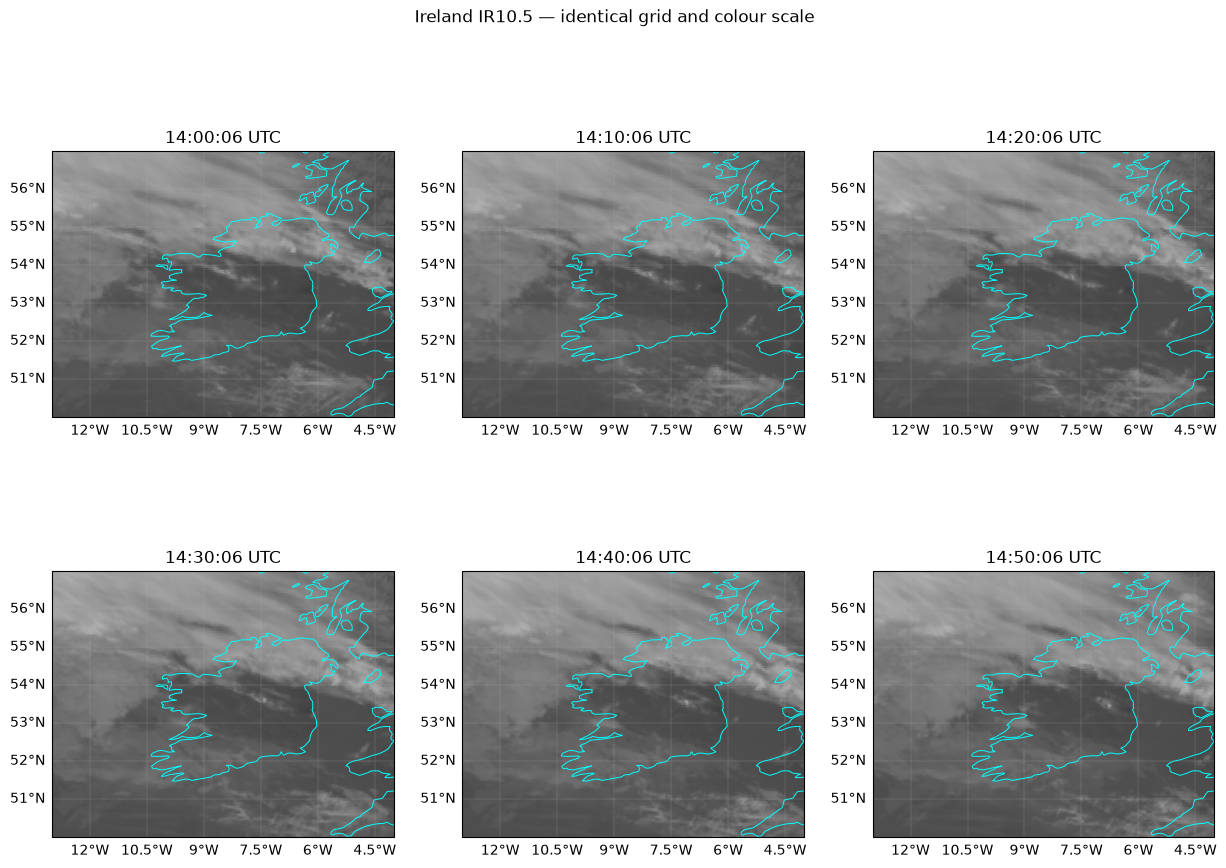

In [5]:
# Prepare the first observation, then prepare the remaining ones.
sample = process_observation(selected[0])
temperature_frames = [sample]
for record in selected[1:]:
    temperature_frames.append(process_observation(record))
    print(f"Processed {record['time']:%H:%M:%S} UTC")
# Stack the images as (number of times, image height, image width).
temperature = np.stack(temperature_frames)
# Keep times in the same order as the image array.
times = [record["time"] for record in selected]
if len(times) < 2:
    raise ValueError("One valid image was obtained. Expand the time range for comparisons.")

# Arrange the observations in rows of up to three panels.
columns = min(3, len(times))
rows = (len(times) + columns - 1) // columns
fig, axes = plt.subplots(rows, columns, figsize=(5*columns, 5*rows), squeeze=False,
                         subplot_kw={"projection": ccrs.PlateCarree()})
# Hide empty panels before drawing the available images.
for ax in axes.flat:
    ax.set_visible(False)
for ax, values, observed_at in zip(axes.flat, temperature, times):
    ax.set_visible(True)
    draw_region(ax, values, f"{observed_at:%H:%M:%S} UTC")
fig.suptitle("Ireland IR10.5 — identical grid and colour scale")
# Save the overview figure and also display it in the notebook.
fig.savefig(RESULTS / "ireland_sequence.png", dpi=160, bbox_inches="tight")
plt.show()


## 6. Set up a repeatable run

The random seeds fix the starting random choices. This experiment uses the CPU and asks PyTorch to use repeatable operations. These settings help make repeated runs easier to compare; they are not a promise that every software environment will give identical numbers.

The `model_cache` folder stores the downloaded ResNet18 weights so they can be reused.


In [6]:
# Fix the starting random choices for Python, NumPy, and PyTorch.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
# Limit CPU threads and request repeatable operations.
torch.set_num_threads(min(4, torch.get_num_threads()))
torch.use_deterministic_algorithms(True)
DEVICE = torch.device('cpu')  # Small, reproducible classroom experiment.
# Reuse downloaded model weights from a local folder.
torch.hub.set_dir(str(Path('model_cache').resolve()))

## 7. Check the prepared data

Before comparing or training, we check that there are exactly **six images**, about **10 minutes apart**, and no missing or infinite pixel values. A failed check stops the notebook rather than silently using unsuitable data.

`extent` provides the map limits for plotting. `labels` names the observation times, and `pair_labels` names each transition, such as `14:00 → 14:10`.


In [7]:
# Reuse the data already prepared above; no NPZ loading is needed.
# Use the existing image values in a numeric format suitable for PyTorch.
temperature = np.asarray(temperature, dtype=np.float32)
bbox = np.asarray(BBOX, dtype=float)

# Check the assumptions required by the temporal split and model.
if temperature.ndim != 3 or temperature.shape[0] != len(times):
    raise ValueError("Expected temperature with shape (time, height, width).")

# The training, validation, and test split below is written for six times.
if len(times) != 6:
    raise ValueError("This experiment expects six observations.")

# Calculate each gap in minutes rather than assuming the times are regular.
intervals = np.array([
    (b - a).total_seconds() / 60
    for a, b in zip(times[:-1], times[1:])
])

if not np.allclose(intervals, 10, atol=0.2):
    raise ValueError("Expected consecutive observations about 10 minutes apart.")

# This model does not handle missing pixels, so stop if any remain.
if not np.isfinite(temperature).all():
    raise ValueError("Missing pixels must be handled before training.")

# Prepare coordinates and labels for the following plots.
west, south, east, north = bbox
# Plotting expects a different coordinate order from BBOX.
extent = (west, east, south, north)

labels = [t.strftime("%H:%M") for t in times]
pair_labels = [
    f"{a}\n→ {b}"
    for a, b in zip(labels[:-1], labels[1:])
]

print(f"{len(times)} observations; grid {temperature.shape[1:]}; "f"intervals {intervals} minutes")
print(f"Brightness temperature: "f"{temperature.min():.2f}–{temperature.max():.2f} K")

6 observations; grid (280, 360); intervals [10. 10. 10. 10. 10.] minutes
Brightness temperature: 226.41–293.95 K


## 8. Measure changes between images

For every pair of consecutive images, we subtract the earlier image from the later one and take the absolute value. The result shows **how much each pixel changed**, without distinguishing increases from decreases. `pixel_mae` is the average of these changes across the whole image, in K.

The five maps share one colour scale. Values above the 99th percentile use the brightest colour, so a few large changes do not dominate the display. This is an observed-change calculation, not a prediction model.


Text(0.5, 0.98, 'Observed 10-minute changes — common display scale (top 1% saturated)')

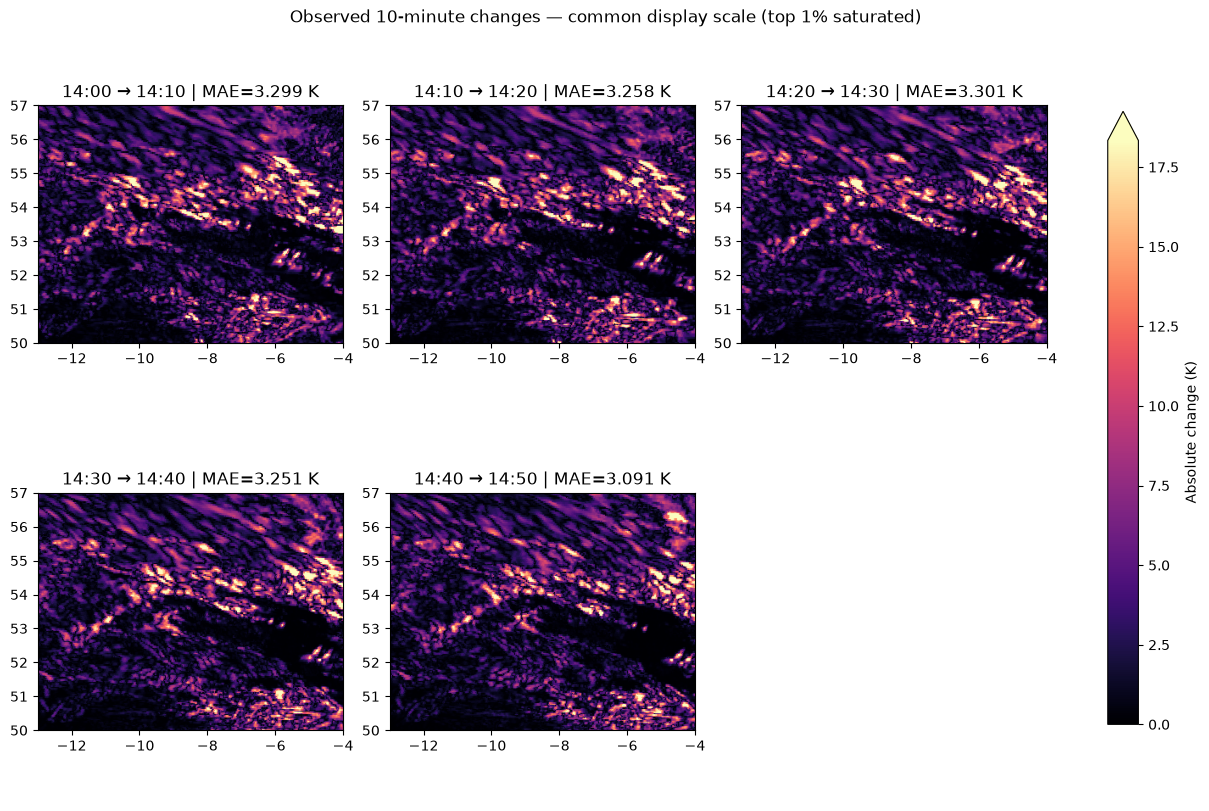

In [8]:
# Subtract consecutive times, then ignore the sign of each change.
absolute_change=np.abs(np.diff(temperature,axis=0))
# Average over image rows and columns to get one score per time pair.
pixel_mae=absolute_change.mean(axis=(1,2))
# Also calculate the signed average; it is not used in later cells.
signed_mean=np.diff(temperature,axis=0).mean(axis=(1,2))
fig,axes=plt.subplots(2,3,figsize=(12,8),layout='constrained')
# Share one display limit across all five change maps.
vmax=float(np.quantile(absolute_change,0.99))
for i,ax in enumerate(axes.flat):
    # There are five time pairs, so hide the sixth panel.
    if i==len(pixel_mae):
        ax.axis('off'); continue
    artist=ax.imshow(absolute_change[i],origin='upper',extent=extent,cmap='magma',vmin=0,vmax=vmax)
    ax.set_title(f'{labels[i]} → {labels[i+1]} | MAE={pixel_mae[i]:.3f} K')
fig.colorbar(artist,ax=axes.ravel().tolist(),shrink=0.8,extend='max',label='Absolute change (K)')
fig.suptitle('Observed 10-minute changes — common display scale (top 1% saturated)')

## 9. Compare image features with ResNet18

Here we use ResNet18 as an **image summariser**, not as the forecasting model. Its weights stay fixed. We replace its final classification step so it returns a list of image features instead of a class label.

The input is scaled, copied into three channels, padded to a square, and resized to 224 × 224 pixels. Copying the channel does not create new colour information. We then compare the feature lists using **cosine distance**: a larger value means a larger difference in these features.

The two plots use different units. Feature distance is a measure of change, not a weather-event label or a measured detection accuracy. The identical-image check only verifies that comparing an image with itself gives a distance near zero.


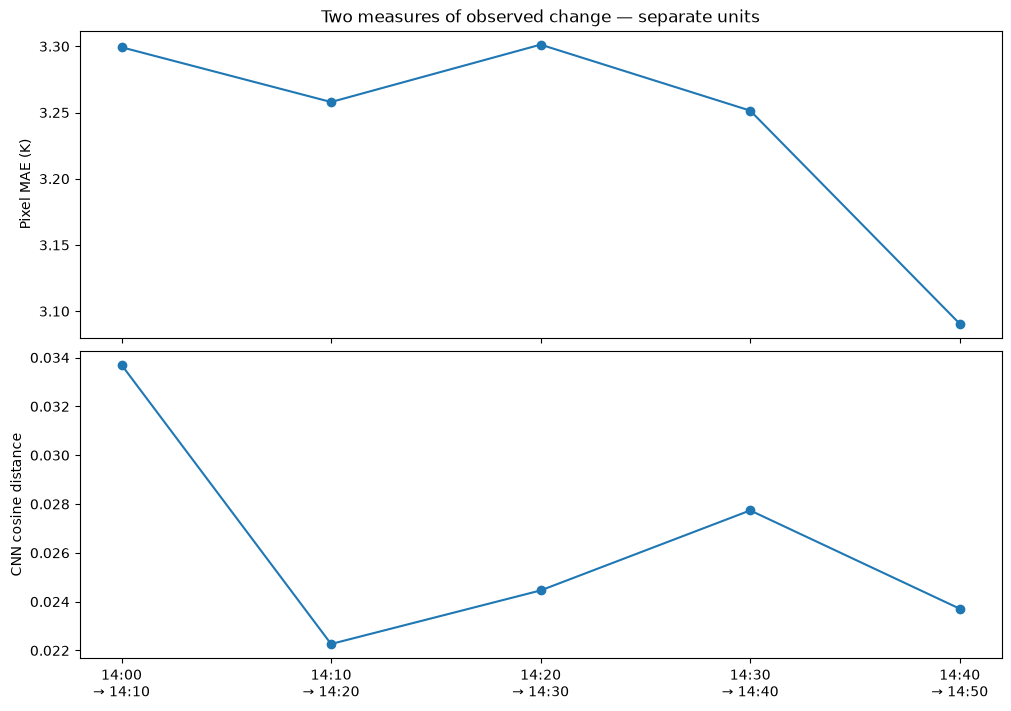

In [9]:
# Load ready-made weights for the image-comparison task.
encoder = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# Return image features instead of the original class predictions.
encoder.fc = nn.Identity()
encoder.eval().to(DEVICE)

# Keep every weight fixed; ResNet18 is not trained on our six images.
for parameter in encoder.parameters():
    parameter.requires_grad_(False)


# Prepare the satellite images for the ready-made network.
def feature_inputs(frames):
    # Invert brightness temperature and replicate the channel as RGB.
    x = torch.from_numpy(np.clip((330.0 - frames) / 150.0, 0, 1))
    # Make three copies of the one measured channel; this is not true colour.
    x = x[:, None].repeat(1, 3, 1, 1)

    # Pad to a square before resizing to preserve the aspect ratio.
    h, w = x.shape[-2:]
    difference = abs(h - w)
    pad_before = difference // 2
    pad_after = difference - pad_before
    padding = (
        (pad_before, pad_after, 0, 0)
        if h > w else (0, 0, pad_before, pad_after)
    )

    # Fill the added border by repeating nearby edge values.
    x = F.pad(x, padding, mode="replicate")
    x = F.interpolate(
        x, size=(224, 224), mode="bilinear",
        align_corners=False, antialias=True,
    )

    # Apply the fixed channel shifts and scales for this network input.
    mean = torch.tensor([0.485, 0.456, 0.406])[None, :, None, None]
    std = torch.tensor([0.229, 0.224, 0.225])[None, :, None, None]
    return (x - mean) / std


# Get features without storing the calculations needed for training.
with torch.inference_mode():
    features = encoder(feature_inputs(temperature).to(DEVICE))
    # Scale each feature list to unit length before comparing it.
    unit_features = F.normalize(features, dim=1)

    # One minus the feature similarity gives one distance per adjacent pair.
    cnn_distance = (
        1 - (unit_features[:-1] * unit_features[1:]).sum(dim=1)
    ).clamp_min(0).cpu().numpy()

    # A simple check: an image compared with itself should have zero distance.
    identical_distance = (
        1 - F.cosine_similarity(features[:1], features[:1])
    ).abs().item()

assert identical_distance < 1e-5

# Plot the two measures separately because their units are different.
pairs = range(len(pixel_mae))
fig, axes = plt.subplots(
    2, 1, figsize=(10, 7), sharex=True, layout="constrained"
)

axes[0].plot(pairs, pixel_mae, "o-")
axes[0].set(ylabel="Pixel MAE (K)", title="Two measures of observed change — separate units",)
axes[1].plot(pairs, cnn_distance, "o-")
axes[1].set(ylabel="CNN cosine distance", xticks=pairs, xticklabels=pair_labels,)

plt.show()

## 10. Prepare training data and build the forecast CNN

This is a **new CNN**, trained here rather than reused from ResNet18. Its input is the current image, and its target is the change to the next image. The current pixel values and nearby pixels are the model's inputs; no extra weather variables are added.

| Use | Earlier image → next image |
|:---|:---|
| Training | 14:00 → 14:10; 14:10 → 14:20; 14:20 → 14:30 |
| Validation: choose the model | 14:30 → 14:40 |
| Test: evaluate the chosen model | 14:40 → 14:50 |

We cut only the training images into **32 × 32 patches**. Shuffling these patches changes their training order, not the time split. The patches come from just three transitions; they are not independent weather sequences.

Inputs are scaled as `(temperature - 270) / 30`. The three convolution layers look at nearby pixels and return one predicted change per pixel. The last layer starts at zero, so the initial forecast is **no change**. We ignore three pixels around the edges when calculating training and evaluation errors.


In [10]:
# Pair i means image i predicts image i + 1. Keep later pairs out of training.
train_pairs = [0, 1, 2]
validation_pair = 3
test_pair = 4

# Use 32 x 32 training patches and exclude a 3-pixel edge from the loss.
PATCH, BORDER = 32, 3
# Use fixed values to put the temperatures on a smaller numerical scale.
CENTER_K, SCALE_K = 270.0, 30.0
# Train for 30 passes, using up to 32 patches per weight update.
EPOCHS, BATCH_SIZE = 30, 32
LEARNING_RATE = 1e-3

# Input: current image. Target: change over the next 10 minutes.
# Add one channel axis: (time, 1, height, width).
x_all = torch.from_numpy((temperature - CENTER_K) / SCALE_K)[:, None]
# The target is later minus earlier, on the same scaled units as the input.
delta_all = x_all[1:] - x_all[:-1]

# Cut input and target at matching positions, using only training pairs.
patch_x, patch_y = [], []
for pair in train_pairs:
    for y in range(0, temperature.shape[1] - PATCH + 1, PATCH):
        for x in range(0, temperature.shape[2] - PATCH + 1, PATCH):
            patch_x.append(x_all[pair, :, y:y + PATCH, x:x + PATCH])
            patch_y.append(delta_all[pair, :, y:y + PATCH, x:x + PATCH])

# Keep each input patch together with its correct target patch.
train_data = TensorDataset(torch.stack(patch_x), torch.stack(patch_y))
# Shuffle the training patches, not the time split.
loader = DataLoader(
    train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=0,
    generator=torch.Generator().manual_seed(SEED),
)


# A small network that predicts a change, rather than the full next image.
class ResidualCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Each convolution looks at 3 x 3 neighbours; the last returns one change channel.
        self.layers = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1, padding_mode="reflect"),
            nn.ReLU(),
            nn.Conv2d(16, 16, 3, padding=1, padding_mode="reflect"),
            nn.ReLU(),
            nn.Conv2d(16, 1, 3, padding=1, padding_mode="reflect"),
        )

        # Zero initial change corresponds to a persistence forecast.
        nn.init.zeros_(self.layers[-1].weight)
        nn.init.zeros_(self.layers[-1].bias)

    # Pass an input image or patch through the three convolution layers.
    def forward(self, x):
        return self.layers(x)


def interior(x):
    # Exclude the boundary affected by convolution padding.
    # Apply the same edge removal to predictions and targets.
    return x[..., BORDER:-BORDER, BORDER:-BORDER]


# Measure validation error without changing model weights.
@torch.inference_mode()
def validation_mae():
    model.eval()
    residual = model(x_all[validation_pair:validation_pair + 1].to(DEVICE))
    target = delta_all[validation_pair:validation_pair + 1].to(DEVICE)
    # Convert the average absolute error back to K for reporting.
    return interior(residual - target).abs().mean().item() * SCALE_K


# Fix the starting weights of this new CNN independently of earlier model loading.
torch.manual_seed(SEED)
model = ResidualCNN().to(DEVICE)
# Adam will adjust the weights using the errors calculated during training.
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"{len(train_data)} correlated training patches from {len(train_pairs)} transitions")
print(f"{sum(p.numel() for p in model.parameters()):,} trainable parameters")

264 correlated training patches from 3 transitions
2,625 trainable parameters


## 11. Train and select a model

An **epoch** is one pass through the training patches. For 30 epochs, the model predicts the change for each batch of patches, measures the error, and adjusts its weights. After each epoch, it is checked on the validation transition without updating the weights.

We keep a separate copy of the weights with the lowest validation MAE, including the initial no-change model as a candidate. After training, those weights are restored. The test transition is not used to choose the model. Lower values on the learning curves mean smaller errors.


Epoch 01: train 3.3342 K; validation 3.2596 K
Epoch 05: train 3.2635 K; validation 3.1695 K
Epoch 10: train 3.1246 K; validation 2.9806 K
Epoch 15: train 3.0375 K; validation 2.8584 K
Epoch 20: train 2.9891 K; validation 2.7328 K
Epoch 25: train 2.7968 K; validation 2.7036 K
Epoch 30: train 2.7672 K; validation 2.6846 K


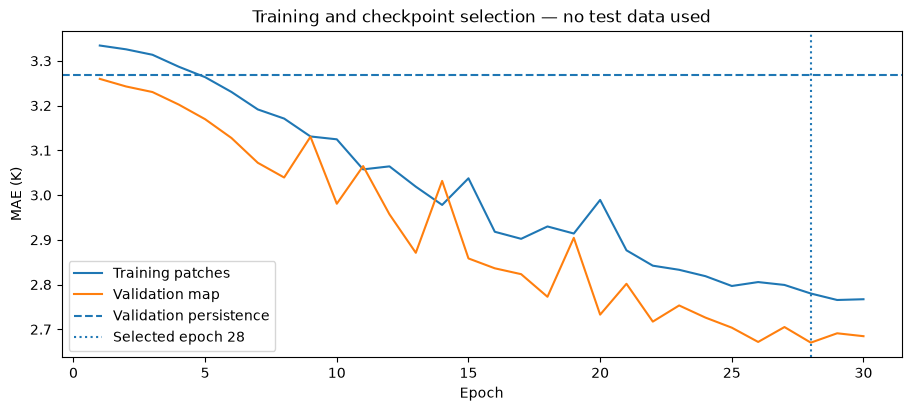

Selected epoch 28; validation MAE 2.6702 K


In [11]:
# The zero-change starting model provides the validation persistence score.
initial_validation = validation_mae()
best_validation = initial_validation
best_epoch = 0
# Keep a separate in-memory copy so later updates cannot overwrite this candidate.
best_state = copy.deepcopy(model.state_dict())
history = []

# One epoch is a full pass through all training patches.
for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, count = 0.0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        # Clear the previous batch's training gradients before a new update.
        optimizer.zero_grad(set_to_none=True)

        # Measure the average absolute difference on the interior pixels.
        loss = F.l1_loss(interior(model(x)), interior(y))
        # Work out how the weights affect this error.
        loss.backward()
        # Update the weights using the calculated gradients.
        optimizer.step()

        # Accumulate the error in K, weighted by the number of patches in the batch.
        total_loss += loss.item() * len(x) * SCALE_K
        count += len(x)

    train_mae = total_loss / count
    # Check the later validation pair once the epoch is finished.
    val_mae = validation_mae()
    history.append([epoch, train_mae, val_mae])

    # Replace the saved candidate only when its validation error is lower.
    if val_mae < best_validation:
        best_validation = val_mae
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:02}: train {train_mae:.4f} K; validation {val_mae:.4f} K")

# Restore the validation-selected model before testing.
model.load_state_dict(best_state)
model.eval()

# Show training and validation error across epochs.
curve = np.asarray(history)
fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")

ax.plot(curve[:, 0], curve[:, 1], label="Training patches")
ax.plot(curve[:, 0], curve[:, 2], label="Validation map")
# The dashed line is the no-change baseline on the validation pair.
ax.axhline(initial_validation, ls="--", label="Validation persistence")
# The vertical line marks the model selected for the test.
ax.axvline(best_epoch, ls=":", label=f"Selected epoch {best_epoch}")

ax.set(
    xlabel="Epoch", ylabel="MAE (K)",
    title="Training and checkpoint selection — no test data used",
)
ax.legend()
plt.show()

print(f"Selected epoch {best_epoch}; validation MAE {best_validation:.4f} K")

## 12. Test the forecast against persistence

The selected CNN predicts the change from **14:40 to 14:50 UTC**. Multiplying its output by `SCALE_K` puts the change back into K. The final forecast is:

**Predicted next image = current image + predicted change.**

The baseline is **persistence**: predict that the next image will be identical to the current one. Both forecasts are scored on the same pixels, excluding the three-pixel border.

| Metric | Meaning |
|:---|:---|
| MAE | Average absolute error. Lower is better. |
| RMSE | An error measure that gives more weight to large errors. Lower is better. |
| Bias | Average predicted value minus observed value. Positive means too high on average; negative means too low. |

The maps show the full images, but the reported scores use only their interior. The earlier change scores used all pixels, so they do not have to match the persistence MAE exactly.


Model             MAE (K)   RMSE (K)   Bias (K)
Persistence         3.103      4.821      0.307
CNN                 2.580      4.031      0.497


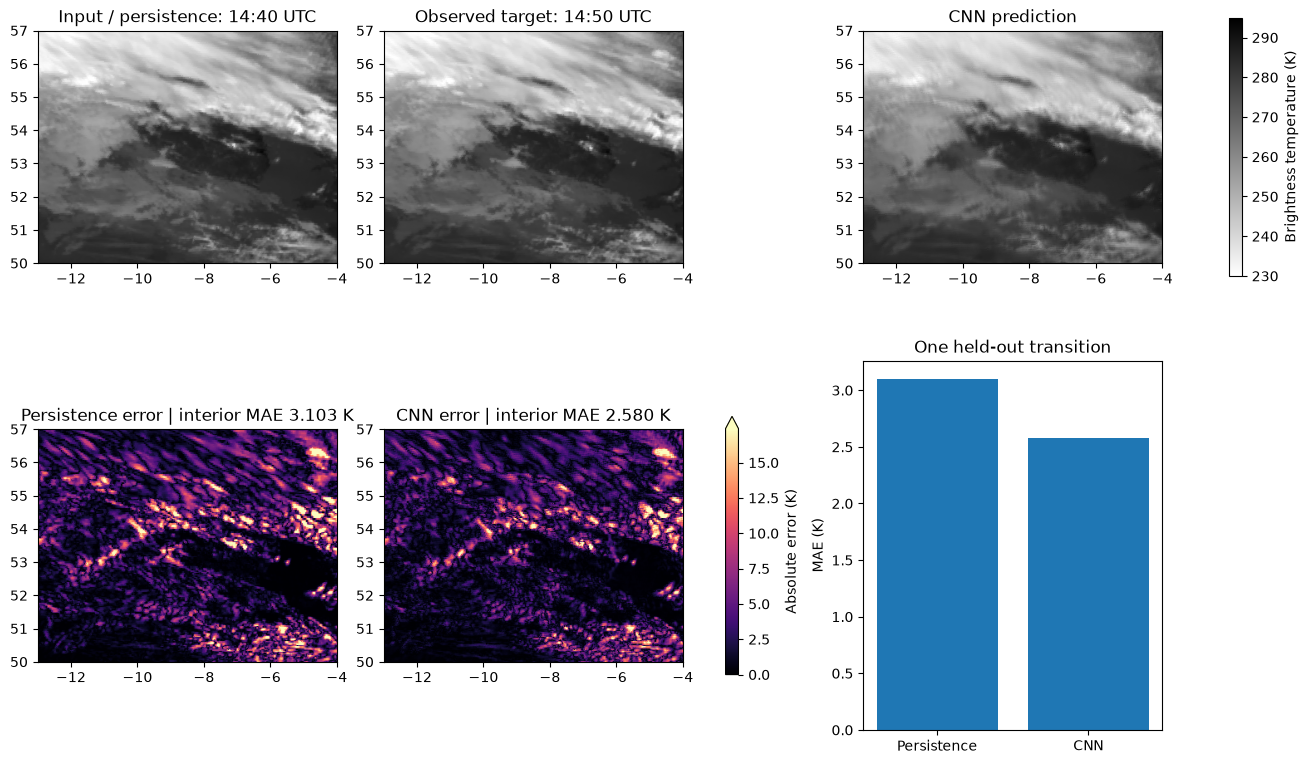

In [12]:
# Predict the next image using the model selected on the validation set.
model.eval()
# Use the restored model without any further training.
with torch.inference_mode():
    # Select the test input, remove the batch/channel axes, and convert the change to K.
    predicted_delta = (
        model(x_all[test_pair:test_pair + 1].to(DEVICE))
        .cpu().numpy()[0, 0] * SCALE_K
    )

# The last pair supplies the current image and its observed next image.
current = temperature[test_pair]
truth = temperature[test_pair + 1]
# Add the predicted change to the current values to obtain a full forecast.
prediction = current + predicted_delta

# Compare CNN with persistence on the same interior pixels.
# Persistence simply reuses the current image as its forecast.
forecasts = {"Persistence": current, "CNN": prediction}
metrics = {}

for name, forecast in forecasts.items():
    # Use the same interior pixels for both forecasts; positive errors mean too high.
    error = (forecast - truth)[BORDER:-BORDER, BORDER:-BORDER]
    # Report average absolute error, error with more weight on large misses, and mean bias.
    metrics[name] = {
        "MAE_K": float(np.abs(error).mean()),
        "RMSE_K": float(np.sqrt(np.mean(error**2))),
        "bias_K": float(error.mean()),
    }

print(f"{'Model':<14} {'MAE (K)':>10} {'RMSE (K)':>10} {'Bias (K)':>10}")
for name, values in metrics.items():
    print(
        f"{name:<14} {values['MAE_K']:>10.3f} "
        f"{values['RMSE_K']:>10.3f} {values['bias_K']:>10.3f}"
    )

# Top row: input, observed target, and CNN prediction.
fig, axes = plt.subplots(2, 3, figsize=(13, 8), layout="constrained")

panels = [
    (current, f"Input / persistence: {labels[test_pair]} UTC"),
    (truth, f"Observed target: {labels[test_pair + 1]} UTC"),
    (prediction, "CNN prediction"),
]

for ax, (values, title) in zip(axes[0], panels):
    art = ax.imshow(
        values, origin="upper", extent=extent,
        cmap="gray_r", vmin=230, vmax=295,
    )
    ax.set_title(title)

fig.colorbar(
    art, ax=axes[0].tolist(), shrink=0.7,
    label="Brightness temperature (K)",
)

# Bottom row: error maps on a common scale, followed by MAE comparison.
# Use a shared display limit based on each map's 99th-percentile error.
error_limit = max(
    float(np.quantile(np.abs(forecast - truth), 0.99))
    for forecast in forecasts.values()
)

for ax, (name, forecast) in zip(axes[1, :2], forecasts.items()):
    art = ax.imshow(
        np.abs(forecast - truth), origin="upper", extent=extent,
        cmap="magma", vmin=0, vmax=max(error_limit, 1e-6),
    )
    ax.set_title(
        f"{name} error | interior MAE {metrics[name]['MAE_K']:.3f} K"
    )

fig.colorbar(
    art, ax=axes[1, :2].tolist(), shrink=0.7,
    label="Absolute error (K)", extend="max",
)

# Compare the two interior MAE values; a shorter bar means lower error.
axes[1, 2].bar(
    list(metrics),
    [values["MAE_K"] for values in metrics.values()],
)
axes[1, 2].set(ylabel="MAE (K)", title="One held-out transition")

plt.show()

## 13. Summarise the test result

The relative MAE skill is `1 - CNN MAE / persistence MAE`. A positive value means the CNN has lower MAE; a negative value means persistence has lower MAE. The ratio is not defined when persistence MAE is zero.

A skill of about **+16.86%** means about **16.86% lower MAE on this test transition**, not a 16.86% increase in classification accuracy. This small experiment is a demonstration, not evidence of reliable performance across different days or weather conditions.


In [13]:
# Reuse the test scores already calculated; no saved data file is needed.
baseline_mae = metrics["Persistence"]["MAE_K"]
cnn_mae = metrics["CNN"]["MAE_K"]

print(f"Test forecast: {labels[test_pair]} → {labels[test_pair + 1]} UTC")

# Avoid dividing by zero when the no-change forecast is already perfect.
if baseline_mae > 0:
    # For example, 0.10 means a 10% reduction in MAE compared with persistence.
    skill = 1 - cnn_mae / baseline_mae
    print(f"CNN MAE skill vs persistence: {skill:+.2%}")
    print("Positive skill = lower MAE; negative skill = higher MAE.")
else:
    print("Relative skill is undefined because persistence MAE is zero.")

# Keep the small size of the experiment visible when reporting the result.
print(
    "Limitation: only six observations and one held-out transition; "
    "this experiment does not establish general forecasting performance."
)

Test forecast: 14:40 → 14:50 UTC
CNN MAE skill vs persistence: +16.86%
Positive skill = lower MAE; negative skill = higher MAE.
Limitation: only six observations and one held-out transition; this experiment does not establish general forecasting performance.


### Reading the saved result

In the saved run, CNN MAE was **2.580 K**, compared with **3.103 K** for persistence. RMSE was also lower, but the average bias increased from **+0.307 K** to **+0.497 K**. So the CNN did not improve every metric.

These numbers describe only the **14:40 → 14:50 UTC** test transition. The many training patches still come from just three time transitions; they do not establish performance across other weather situations.
